In [1]:
import yfinance as yf
import pandas as pd
import sqlite3
import os

# 1. Καθαρισμός αν υπάρχει ήδη προβληματικό αρχείο
db_name = 'portfolio_research.db'
if os.path.exists(db_name):
    try:
        os.remove(db_name)
    except:
        print("Το αρχείο είναι ανοιχτό σε άλλο πρόγραμμα (π.χ. DBeaver). Κλείσε τη σύνδεση και ξαναδοκίμασε.")

# 2. Λίστα με τις μετοχές
tickers = ['AAPL', 'JPM', 'XOM', 'JNJ', 'WMT']

# 3. Λήψη δεδομένων
print("Downloading data...")
data = yf.download(tickers, start='2023-01-01', end='2026-12-31')

# Επιλογή τιμών (Handle MultiIndex)
if 'Adj Close' in data.columns:
    clean_data = data['Adj Close']
else:
    clean_data = data['Close']

# Μετατροπή σε Long Format (Date, Ticker, Price)
df_melted = clean_data.reset_index().melt(id_vars='Date', var_name='Ticker', value_name='Price')
df_melted['Date'] = pd.to_datetime(df_melted['Date']).dt.strftime('%Y-%m-%d')
df_melted = df_melted.dropna(subset=['Price'])

# 4. Αποθήκευση στην SQLite
with sqlite3.connect(db_name) as conn:
    df_melted.to_sql('stock_prices', conn, if_exists='replace', index=False)
    conn.execute("CREATE INDEX IF NOT EXISTS idx_ticker_date ON stock_prices (Ticker, Date)")
    print("---")
    print(f"Success! Το αρχείο {db_name} δημιουργήθηκε σωστά.")
    print(f"Rows added: {len(df_melted)}")

[*********************100%***********************]  5 of 5 completed

---
Success! Το αρχείο portfolio_research.db δημιουργήθηκε σωστά.
Rows added: 3955


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 1. Ανάγνωση δεδομένων από την SQLite βάση μας
conn = sqlite3.connect('portfolio_research.db')
df = pd.read_sql("SELECT * FROM stock_prices", conn)
conn.close()

In [4]:
# 2. Προετοιμασία Πίνακα (Pivot) για να έχουμε τις μετοχές σε στήλες
df_pivot = df.pivot(index='Date', columns='Ticker', values='Price')

In [5]:
# 3. Τα Μαθηματικά στην Πράξη: Λογαριθμικές Αποδόσεις
log_returns = np.log(df_pivot / df_pivot.shift(1)).dropna()

In [6]:
# 4. Υπολογισμός Ρίσκου & Απόδοσης (Ετησιοποιημένα με 252 μέρες)
summary_stats = pd.DataFrame({
    'Annual Return (%)': log_returns.mean() * 252 * 100,
    'Annual Volatility (%)': log_returns.std() * np.sqrt(252) * 100 
})
print("--- Στατιστικά Χαρτοφυλακίου ---")
print(summary_stats.round(2).sort_values(by='Annual Return (%)', ascending=False))

--- Στατιστικά Χαρτοφυλακίου ---
        Annual Return (%)  Annual Volatility (%)
Ticker                                          
WMT                 32.53                  20.31
JPM                 27.98                  23.37
AAPL                24.36                  25.57
XOM                 14.95                  23.12
JNJ                 13.68                  17.21


<Figure size 800x600 with 0 Axes>

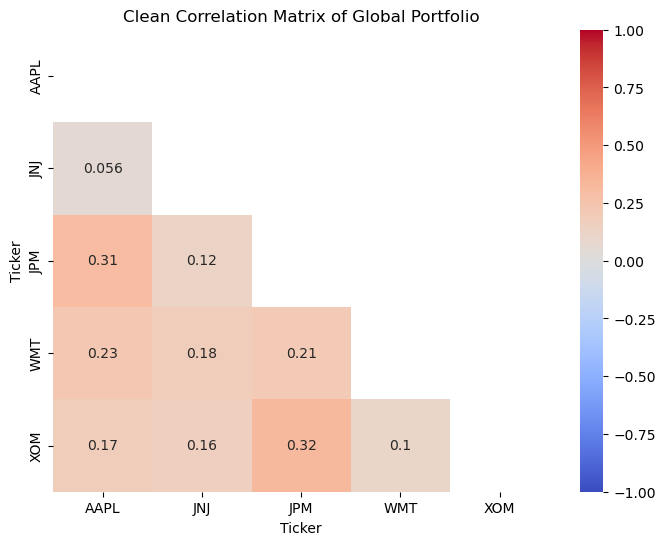

In [7]:
# 5. Οπτικοποίηση της Συσχέτισης (Correlation Matrix)
plt.figure(figsize=(8, 6))
# Το .corr() φτιάχνει τον πίνακα με τα ρ για όλους τους συνδυασμούς
# Υπολογισμός του πίνακα συσχέτισης
corr_matrix = log_returns.corr()

# Δημιουργία της 'μάσκας' για να κρύψουμε το πάνω δεξιά τρίγωνο
# Το np.triu (Triangle Upper) εντοπίζει το πάνω μισό του πίνακα
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Οπτικοποίηση (Προσθέτουμε την παράμετρο mask=mask)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, mask=mask)
plt.title('Clean Correlation Matrix of Global Portfolio')
plt.show()

In [8]:
# Ορίζουμε 10.000 διαφορετικά σενάρια
num_portfolios = 10000
num_assets = len(df_pivot.columns)

# Κενοί πίνακες για να σώσουμε τα αποτελέσματα
results = np.zeros((3, num_portfolios))
weights_record = []

# Ετησιοποιημένες αποδόσεις και Covariance Matrix (εδώ μπαίνει η θεωρία μας!)
annual_returns = log_returns.mean() * 252
cov_matrix = log_returns.cov() * 252

print("Τρέχουν 10.000 προσομοιώσεις... Παρακαλώ περιμένετε.")

Τρέχουν 10.000 προσομοιώσεις... Παρακαλώ περιμένετε.


In [9]:
for i in range(num_portfolios):
    # Παράγουμε τυχαία ποσοστά που το άθροισμά τους κάνει 100% (1.0)
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    weights_record.append(weights)
    
    # Υπολογισμός Απόδοσης και Ρίσκου για το κάθε τυχαίο χαρτοφυλάκιο
    portfolio_return = np.sum(weights * annual_returns)
    portfolio_std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    
    # Υπολογισμός Sharpe Ratio (Απόδοση / Ρίσκο)
    sharpe_ratio = portfolio_return / portfolio_std_dev
    
    # Αποθήκευση
    results[0,i] = portfolio_std_dev
    results[1,i] = portfolio_return
    results[2,i] = sharpe_ratio

print("Ολοκληρώθηκε! Σχεδίαση Αποτελεσματικής Μεθορίου...")

Ολοκληρώθηκε! Σχεδίαση Αποτελεσματικής Μεθορίου...


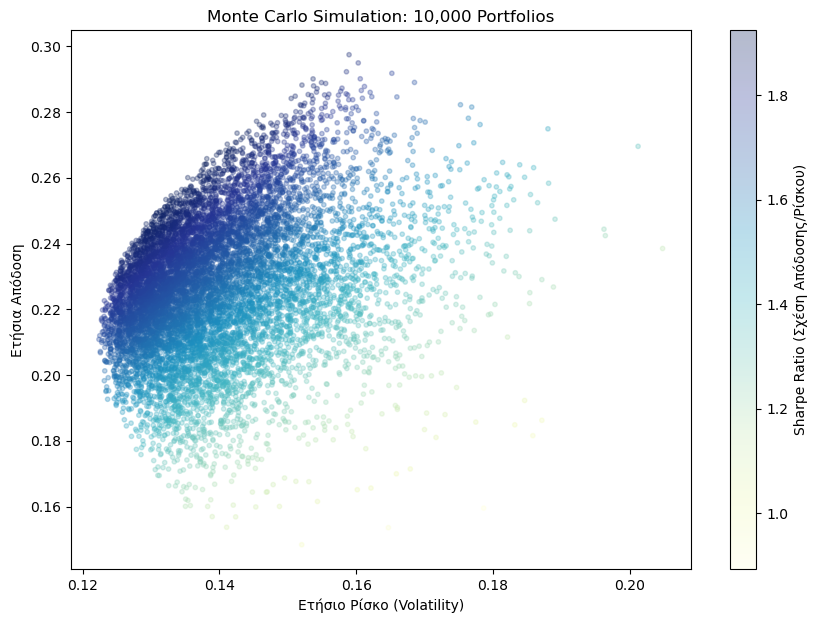

In [10]:
# Οπτικοποίηση
plt.figure(figsize=(10, 7))
plt.scatter(results[0,:], results[1,:], c=results[2,:], cmap='YlGnBu', marker='o', s=10, alpha=0.3)
plt.colorbar(label='Sharpe Ratio (Σχέση Απόδοσης/Ρίσκου)')
plt.title('Monte Carlo Simulation: 10,000 Portfolios')
plt.xlabel('Ετήσιο Ρίσκο (Volatility)')
plt.ylabel('Ετήσια Απόδοση')
plt.show()

In [11]:
# Θεματική 1: Το Βέλτιστο Χαρτοφυλάκιο (Max Sharpe Ratio - Κόκκινο Αστέρι)
max_sharpe_idx = np.argmax(results[2])
max_sharpe_return = results[1, max_sharpe_idx]
max_sharpe_volatility = results[0, max_sharpe_idx]
max_sharpe_weights = weights_record[max_sharpe_idx]

In [12]:
# Θεματική 2: Το Πιο Ασφαλές Χαρτοφυλάκιο (Minimum Volatility - Πράσινο Αστέρι)
min_vol_idx = np.argmin(results[0])
min_vol_return = results[1, min_vol_idx]
min_vol_volatility = results[0, min_vol_idx]
min_vol_weights = weights_record[min_vol_idx]

In [13]:
# Θεματική 3: Το Λιγότερο Ασφαλές / Πιο Ριψοκίνδυνο (Maximum Volatility - Μαύρο Αστέρι)
max_vol_idx = np.argmax(results[0]) # Ψάχνουμε το ΜΕΓΙΣΤΟ νούμερο στον άξονα του ρίσκου
max_vol_return = results[1, max_vol_idx]
max_vol_volatility = results[0, max_vol_idx]
max_vol_weights = weights_record[max_vol_idx]

In [14]:
# --- ΕΚΤΥΠΩΣΗ ΑΠΟΤΕΛΕΣΜΑΤΩΝ ---
print("\n" + "="*50)
print("ΤΟ ΒΕΛΤΙΣΤΟ ΧΑΡΤΟΦΥΛΑΚΙΟ (Max Sharpe Ratio)")
print("="*50)
print(f"Αναμενόμενη Απόδοση: {max_sharpe_return*100:.2f}% | Ετήσιο Ρίσκο: {max_sharpe_volatility*100:.2f}%")
for i, ticker in enumerate(df_pivot.columns):
    print(f" - {ticker}: {max_sharpe_weights[i]*100:.2f}%")


ΤΟ ΒΕΛΤΙΣΤΟ ΧΑΡΤΟΦΥΛΑΚΙΟ (Max Sharpe Ratio)
Αναμενόμενη Απόδοση: 26.58% | Ετήσιο Ρίσκο: 13.82%
 - AAPL: 11.86%
 - JNJ: 17.05%
 - JPM: 21.12%
 - WMT: 45.40%
 - XOM: 4.57%


In [15]:
print("\n" + "="*50)
print("ΤΟ ΠΙΟ ΑΣΦΑΛΕΣ ΧΑΡΤΟΦΥΛΑΚΙΟ (Minimum Volatility)")
print("="*50)
print(f"Αναμενόμενη Απόδοση: {min_vol_return*100:.2f}% | Ετήσιο Ρίσκο: {min_vol_volatility*100:.2f}%")
for i, ticker in enumerate(df_pivot.columns):
    print(f" - {ticker}: {min_vol_weights[i]*100:.2f}%")


ΤΟ ΠΙΟ ΑΣΦΑΛΕΣ ΧΑΡΤΟΦΥΛΑΚΙΟ (Minimum Volatility)
Αναμενόμενη Απόδοση: 21.08% | Ετήσιο Ρίσκο: 12.24%
 - AAPL: 9.77%
 - JNJ: 40.92%
 - JPM: 12.67%
 - WMT: 23.23%
 - XOM: 13.41%


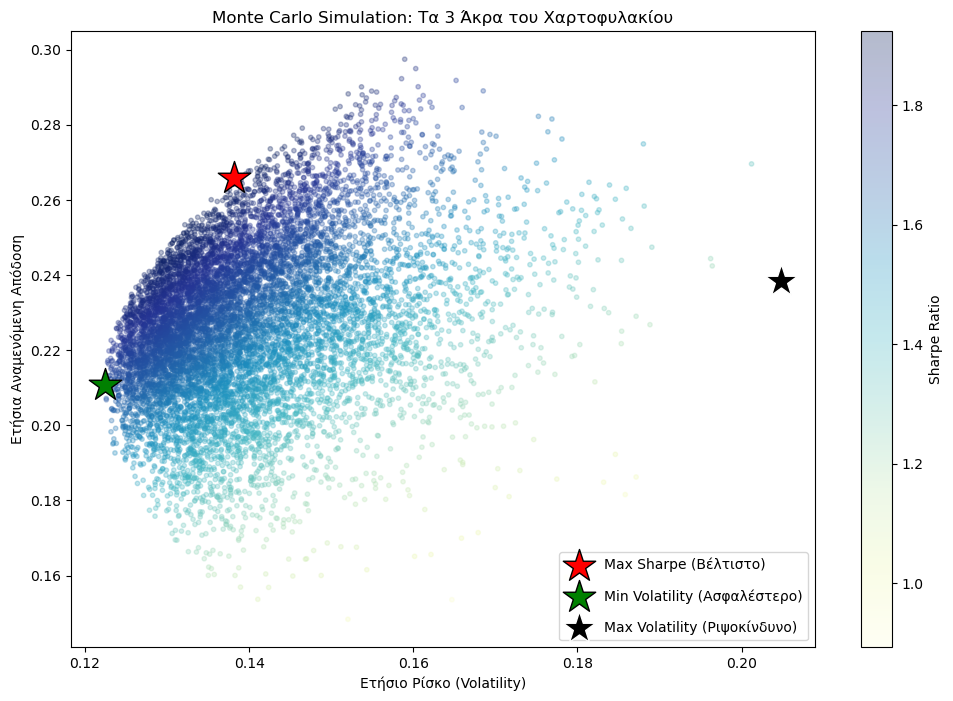

In [16]:
# --- ΟΠΤΙΚΟΠΟΙΗΣΗ ---
plt.figure(figsize=(12, 8))
plt.scatter(results[0,:], results[1,:], c=results[2,:], cmap='YlGnBu', marker='o', s=10, alpha=0.3)
plt.colorbar(label='Sharpe Ratio')

# Καρφιτσώνουμε τα 3 Αστέρια
plt.scatter(max_sharpe_volatility, max_sharpe_return, marker='*', color='red', s=600, label='Max Sharpe (Βέλτιστο)', edgecolor='black')
plt.scatter(min_vol_volatility, min_vol_return, marker='*', color='green', s=600, label='Min Volatility (Ασφαλέστερο)', edgecolor='black')
plt.scatter(max_vol_volatility, max_vol_return, marker='*', color='black', s=600, label='Max Volatility (Ριψοκίνδυνο)', edgecolor='white')

plt.title('Monte Carlo Simulation: Τα 3 Άκρα του Χαρτοφυλακίου')
plt.xlabel('Ετήσιο Ρίσκο (Volatility)')
plt.ylabel('Ετήσια Αναμενόμενη Απόδοση')
plt.legend(labelspacing=1.2, loc='lower right')
plt.show()